# Project — Chapter 119: 2D Geometry Visualizer

> **Prerequisites:** ch091–118 (full Part IV)
>
> **Concepts:** All geometric primitives, transformations, intersections, Bézier curves
>
> **Output:** A reusable 2D geometry library with visualization

---

## Overview

Build a complete 2D geometry library that can represent, transform, and visualize:
points, lines, line segments, circles, polygons, and Bézier curves.
All transformations use the affine framework from ch114.

## Stage 1 — Geometry Data Classes

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

class Point:
    def __init__(self, x, y):
        self.coords = np.array([x, y], dtype=float)
    def __repr__(self): return f"Point({self.coords[0]:.3f}, {self.coords[1]:.3f})"
    def distance_to(self, other): return np.linalg.norm(self.coords - other.coords)
    def to_homogeneous(self): return np.append(self.coords, 1.0)

class LineSegment:
    def __init__(self, p1, p2):
        self.p1 = Point(*p1) if not isinstance(p1,Point) else p1
        self.p2 = Point(*p2) if not isinstance(p2,Point) else p2
    def length(self): return self.p1.distance_to(self.p2)
    def midpoint(self): return Point(*(0.5*(self.p1.coords+self.p2.coords)))
    def point_at(self, t): return Point(*((1-t)*self.p1.coords + t*self.p2.coords))
    def to_standard(self):
        dx = self.p2.coords[0]-self.p1.coords[0]
        dy = self.p2.coords[1]-self.p1.coords[1]
        a,b = -dy, dx; c = -(a*self.p1.coords[0]+b*self.p1.coords[1])
        return a,b,c

class Circle:
    def __init__(self, cx, cy, r):
        self.center = Point(cx, cy); self.r = r
    def contains(self, p):
        return self.center.distance_to(p) < self.r
    def intersects_circle(self, other):
        return self.center.distance_to(other.center) < self.r + other.r
    def area(self): return np.pi * self.r**2
    def circumference(self): return 2 * np.pi * self.r

class Polygon:
    def __init__(self, vertices):
        self.verts = np.array(vertices, dtype=float)
    def perimeter(self):
        verts = np.vstack([self.verts, self.verts[0]])
        return sum(np.linalg.norm(verts[i+1]-verts[i]) for i in range(len(self.verts)))
    def area(self):
        x, y = self.verts[:,0], self.verts[:,1]
        return 0.5 * abs(np.dot(x, np.roll(y,-1)) - np.dot(y, np.roll(x,-1)))
    def apply_transform(self, M_3x3):
        h = np.hstack([self.verts, np.ones((len(self.verts),1))])
        out = (M_3x3 @ h.T).T
        return Polygon(out[:,:2] / out[:,2:3])

# Demo
p1, p2 = Point(0,0), Point(3,4)
seg = LineSegment(p1, p2)
print(f"Segment length: {seg.length()}")  # 5
print(f"Midpoint: {seg.midpoint()}")
c = Circle(0,0,5); print(f"Contains (3,4)? {c.contains(p2)}")
pentagon_verts = [(np.cos(2*np.pi*i/5), np.sin(2*np.pi*i/5)) for i in range(5)]
pent = Polygon(pentagon_verts)
print(f"Pentagon area: {pent.area():.4f}, perimeter: {pent.perimeter():.4f}")

Segment length: 5.0
Midpoint: Point(1.500, 2.000)
Contains (3,4)? False
Pentagon area: 2.3776, perimeter: 5.8779


## Stage 2 — Transformation Engine

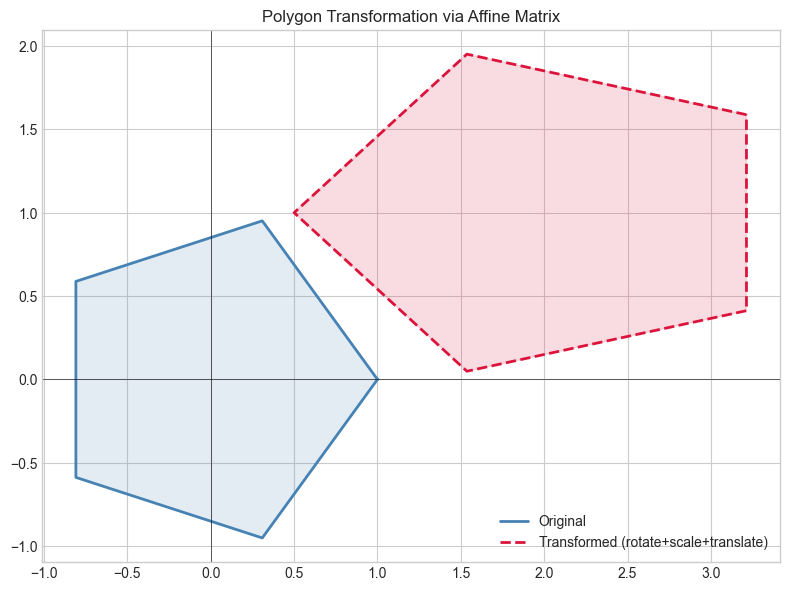

In [3]:
# Stage 2: Transformation matrices using affine framework (ch114)
def make_rotation(theta):
    c,s = np.cos(theta), np.sin(theta)
    return np.array([[c,-s,0],[s,c,0],[0,0,1]])

def make_translation(dx, dy):
    return np.array([[1,0,dx],[0,1,dy],[0,0,1]],dtype=float)

def make_scale(sx, sy):
    return np.array([[sx,0,0],[0,sy,0],[0,0,1]],dtype=float)

def compose(*transforms):
    M = np.eye(3)
    for T in transforms:
        M = T @ M
    return M

# Test: rotate pentagon 36°, scale x by 1.5, translate (2,1)
T = compose(make_rotation(np.radians(36)), make_scale(1.5,1), make_translation(2,1))
pent_transformed = pent.apply_transform(T)

fig, ax = plt.subplots(figsize=(8,6))
def plot_polygon(ax, poly, color, label, linestyle='-'):
    v = np.vstack([poly.verts, poly.verts[0]])
    ax.fill(poly.verts[:,0], poly.verts[:,1], alpha=0.15, color=color)
    ax.plot(v[:,0], v[:,1], color=color, lw=2, linestyle=linestyle, label=label)

plot_polygon(ax, pent, 'steelblue', 'Original')
plot_polygon(ax, pent_transformed, 'crimson', 'Transformed (rotate+scale+translate)', '--')
ax.set_aspect('equal'); ax.legend(); ax.axhline(0, color='k', linewidth=0.4); ax.axvline(0, color='k', linewidth=0.4)
ax.set_title('Polygon Transformation via Affine Matrix')
plt.tight_layout(); plt.show()

## Stage 3 — Intersection Library

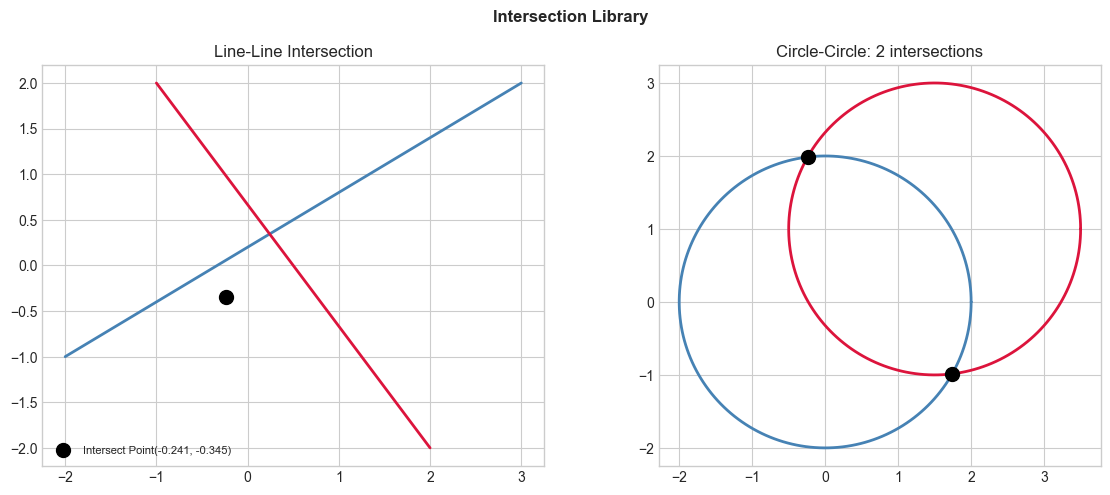

In [4]:
# Stage 3: Geometric intersection tests
def line_line_intersect(seg1, seg2):
    """Find intersection of two line segments (or None if parallel)."""
    a1,b1,c1 = seg1.to_standard()
    a2,b2,c2 = seg2.to_standard()
    det = a1*b2 - a2*b1
    if abs(det) < 1e-10: return None  # parallel
    x = (b1*c2 - b2*c1) / (-det if det else 1)  # Cramer's rule
    y = (a2*c1 - a1*c2) / (-det if det else 1)
    return Point((-b1*c2+b2*c1)/det, (a1*c2-a2*c1)/det)

def circle_circle_intersect(c1, c2):
    d = c1.center.distance_to(c2.center)
    if d > c1.r + c2.r or d < abs(c1.r - c2.r) or d < 1e-10: return []
    a = (c1.r**2 - c2.r**2 + d**2) / (2*d)
    h = np.sqrt(max(0, c1.r**2 - a**2))
    mid = c1.center.coords + a*(c2.center.coords - c1.center.coords)/d
    perp = np.array([-(c2.center.coords[1]-c1.center.coords[1]),
                     c2.center.coords[0]-c1.center.coords[0]]) / d
    return [Point(*(mid + h*perp)), Point(*(mid - h*perp))]

# Visual demo
fig, axes = plt.subplots(1,2,figsize=(12,5))
s1 = LineSegment((-2,-1),(3,2)); s2 = LineSegment((-1,2),(2,-2))
pt = line_line_intersect(s1,s2)
for seg, color in [(s1,'steelblue'),(s2,'crimson')]:
    axes[0].plot([seg.p1.coords[0],seg.p2.coords[0]],[seg.p1.coords[1],seg.p2.coords[1]],color=color,lw=2)
if pt: axes[0].plot(*pt.coords,'ko',ms=10,label=f'Intersect {pt}')
axes[0].legend(fontsize=8); axes[0].set_aspect('equal'); axes[0].set_title('Line-Line Intersection')

theta = np.linspace(0,2*np.pi,200)
c1 = Circle(0,0,2); c2 = Circle(1.5,1,2)
pts = circle_circle_intersect(c1,c2)
for c,color in [(c1,'steelblue'),(c2,'crimson')]:
    axes[1].plot(c.center.coords[0]+c.r*np.cos(theta),c.center.coords[1]+c.r*np.sin(theta),color=color,lw=2)
for p in pts: axes[1].plot(*p.coords,'ko',ms=10)
axes[1].set_aspect('equal'); axes[1].set_title(f'Circle-Circle: {len(pts)} intersections')
plt.suptitle('Intersection Library', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## Stage 4 — Bézier Integration + Full Demo

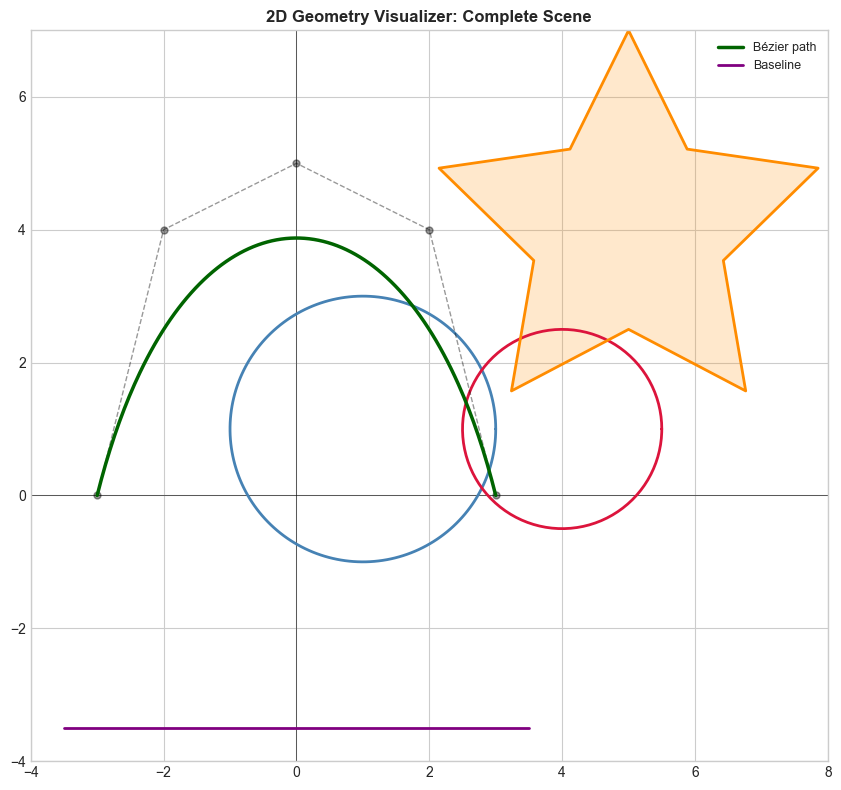

Star polygon: area=13.225, perimeter=19.922


In [6]:
# Stage 4: Bézier curves integrated with the library
def bezier_curve(control_pts, n=200):
    def lerp(a,b,t): return (1-t)*a + t*b
    def de_casteljau(pts, t):
        while len(pts)>1: pts=[lerp(pts[i],pts[i+1],t) for i in range(len(pts)-1)]
        return pts[0]
    t_vals = np.linspace(0,1,n)
    return np.array([de_casteljau([np.asarray(p) for p in control_pts],t) for t in t_vals])

# Full scene
fig, ax = plt.subplots(figsize=(11,8))
ax.set_xlim(-4,8); ax.set_ylim(-4,7); ax.set_aspect('equal')
ax.axhline(0, color='k', linewidth=0.4); ax.axvline(0, color='k', linewidth=0.4)
ax.set_title('2D Geometry Visualizer: Complete Scene', fontsize=12, fontweight='bold')

# Circles
for (cx,cy,r,col) in [(1,1,2,'steelblue'),(4,1,1.5,'crimson')]:
    theta_c = np.linspace(0,2*np.pi,200)
    ax.plot(cx+r*np.cos(theta_c), cy+r*np.sin(theta_c), color=col, lw=2)

# Polygon (star)
n=5; R1,R2=3,1.5
star_pts=[(R1*np.cos(np.pi/2+2*np.pi*k/n+i*np.pi/n),
           R1*np.sin(np.pi/2+2*np.pi*k/n+i*np.pi/n)) if i==0 else
          (R2*np.cos(np.pi/2+(2*k+1)*np.pi/n),R2*np.sin(np.pi/2+(2*k+1)*np.pi/n))
          for k in range(n) for i in range(2)]
star = Polygon(star_pts)
v = np.vstack([star.verts, star.verts[0]])
ax.fill(star.verts[:,0]+5, star.verts[:,1]+4, alpha=0.2, color='darkorange')
ax.plot(v[:,0]+5, v[:,1]+4, 'darkorange', lw=2)

# Bézier path
ctrl = [(-3,0),(-2,4),(0,5),(2,4),(3,0)]
curve = bezier_curve(ctrl)
ax.plot(np.array(ctrl)[:,0], np.array(ctrl)[:,1], 'k--o', lw=1, ms=5, alpha=0.4)
ax.plot(curve[:,0], curve[:,1], 'darkgreen', lw=2.5, label='Bézier path')

# Line segments
ax.plot([-3.5,3.5],[-3.5,-3.5],'purple',lw=2,label='Baseline')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()
print(f"Star polygon: area={star.area():.3f}, perimeter={star.perimeter():.3f}")

## Results & Reflection

**What was built:** A reusable 2D geometry library: Point, LineSegment, Circle, Polygon classes;
affine transformation engine; intersection tests; Bézier integration.

**What math made it possible:** Every chapter of Part IV in one system —
coordinate geometry (ch092–095), lines (ch096–098), circles (ch099),
transformations (ch108–114), curves (ch116).

**Extension challenges:**
1. Add a `ConvexHull` class using Graham scan or QuickHull
2. Add polygon-polygon intersection (Sutherland-Hodgman algorithm)
3. Export the scene to SVG format (the geometry → file pipeline)